In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms

In [33]:
group1 = [3,1,5,4,6,4,6,2,0,5,4,5]
group2 = [4,3,6,6,8,5,5,4,2,5,7,5]
mean1, mean2 = np.mean(group1), np.mean(group2)
std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
mean1, mean2, std1, std2, std1/np.sqrt(len(group1)), std2/np.sqrt(len(group2))

(3.75,
 5.0,
 1.9128750375000738,
 1.651445647689541,
 0.5521994589133916,
 0.4767312946227962)

In [12]:
tost_result = sms.ttost_ind(group1, group2, -0.05, 0.05, usevar='pooled')
tost_result

(0.9428997306385449,
 (-1.644921008606541, 0.9428997306385449, 22.0),
 (-1.7819977593237528, 0.04427952451500204, 22.0))

In [14]:
tost_result = sms.ttost_ind(group1, group2, -3, 3, usevar='unequal')
tost_result


(0.012780635899849782,
 (2.398843137551206, 0.012780635899849782, 21.541405223084748),
 (-5.8257619054814995, 3.976826657957202e-06, 21.541405223084748))

In [59]:
margin = 3
low_margin = -margin
high_margin = margin
mean_diff = mean1 - mean2

In [63]:
import scipy.stats as st


In [74]:
# Sample sizes
n1, n2 = len(group1), len(group2)


## Standard error of the difference (Welch's t-test approach)
sed = np.sqrt((std1**2 / n1) + (std2**2 / n2))

# Degrees of freedom (Welch–Satterthwaite)
df_num = (std1**2 / n1 + std2**2 / n2)**2
df_den = (std1**4 / (n1**2 * (n1-1))) + (std2**4 / (n2**2 * (n2-1)))
df = df_num / df_den

In [ ]:
# t-critical value for 95% CI
alpha = 0.05
t_crit = st.t.ppf(1 - alpha/2, df)

# Confidence interval
ci_lower = mean_diff - t_crit * sed
ci_upper = mean_diff + t_crit * sed

TOST Results: (0.012780635899849782, (2.398843137551206, 0.012780635899849782, 21.541405223084748), (-5.8257619054814995, 3.976826657957202e-06, 21.541405223084748))


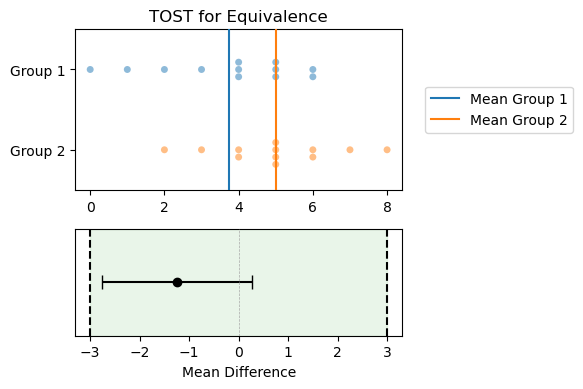

In [78]:
# Create figure with two vertically stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 4), gridspec_kw={'height_ratios': [0.75, 0.5]}, sharex=False)

# Panel 1: Swarm plot
sns.swarmplot(data=[group1, group2], orient='h', ax=axes[0], palette=['tab:blue', 'tab:orange'], alpha=0.5)
axes[0].axvline(mean1, color='tab:blue', label='Mean Group 1', zorder=5)
axes[0].axvline(mean2, color='tab:orange', label='Mean Group 2', zorder=5)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Group 1", "Group 2"])
axes[0].set_title("TOST for Equivalence")

# Panel 2: Mean difference and equivalence margins

axes[1].axvline(0, color='darkgray', lw=0.5, linestyle='--', label='Lower Margin', zorder=5)
axes[1].axvline(low_margin, color='black', linestyle='--', label='Lower Margin', zorder=5)
axes[1].axvline(high_margin, color='black', linestyle='--', label='Upper Margin', zorder=5)
axes[1].axvspan(low_margin, high_margin, color='tab:green', alpha=0.1, zorder=-1)
axes[1].set_yticks([])  # Remove y-axis labels for clarity
axes[1].set_xlabel("Mean Difference")

# Add legend only once
#handles, labels = axes[1].get_legend_handles_labels()
#axes[0].legend(handles, labels, loc='center right')

axes[0].legend(bbox_to_anchor=(1.05, 0.5), loc='center left',)

plt.errorbar(y=0, x=mean_diff, xerr=[[mean_diff - ci_lower], [ci_upper - mean_diff]],
             fmt='o', capsize=5, color='black')

tost_result = sms.ttost_ind(group1, group2, low_margin, high_margin, usevar='unequal')
print("TOST Results:", tost_result)

plt.tight_layout()
plt.show()